# Apriori Algorithm on Online Retail Dataset


## Step 1: Import Libraries

In [ ]:
!pip install mlxtend

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
#Association rule mining	To generate frequent itemsets and association rules using the Apriori algorithm.

## Step 2: Load and Explore Data

In [4]:
df=pd.read_excel('Online Retail.xlsx')
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print(df.shape)

(541909, 8)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
display(df.describe())

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
print(df['Country'].value_counts())

United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon 

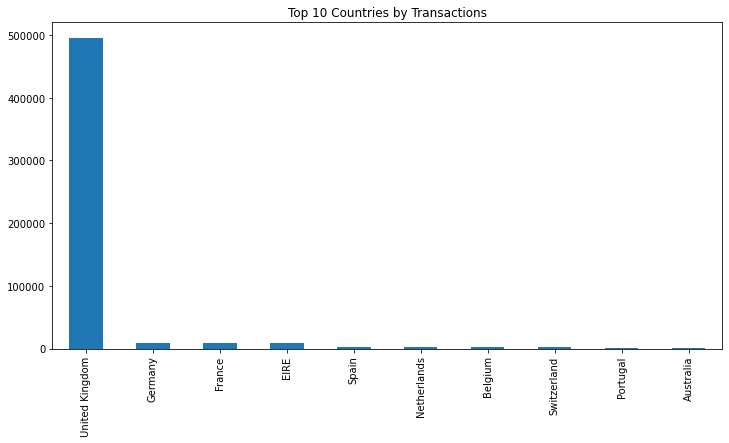

In [10]:
plt.figure(figsize=(12,6))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Transactions')
plt.show()

## Step 3: Clean the Data

In [17]:
CustID = df["CustomerID"].isnull().sum()
Numb= CustID/len(df)

print("Percentage of CustomerID that are missing in the dataset = ",(Numb)*100, "%")

Percentage of CustomerID that are missing in the dataset =  24.926694334288598 %


In [18]:
Desc = df["Description"].isnull().sum()
Numb= Desc/len(df)

print("Percentage of Description that are missing in the dataset = ",(Numb)*100, "%")

Percentage of Description that are missing in the dataset =  0.2683107311375157 %


In [25]:
# To see rows where both Description and CustomerID are missing
df[df['Description'].isna() & df['CustomerID'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


### Why keep the missing CustomerID rows?
- I would lose approximately 135,000 valid product transactions that could contribute to finding frequent itemsets and ---association rules.
- Therefore, I would remove only the rows where the Description column has a missing value (NaN).
- This does not remove rows with missing values in any other column.
### Notice:

- ✅ The row with missing Description was removed.
- ✅ The row with missing CustomerID was kept because the product description is still available.

In [26]:
# Display the rows with missing Description
df.loc[df['Description'].isna(),
       ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'CustomerID', 'Country']]

,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
622,536414,22139,NaN,56,NaN,United Kingdom
1970,536545,21134,NaN,1,NaN,United Kingdom
1971,536546,22145,NaN,1,NaN,United Kingdom
1972,536547,37509,NaN,1,NaN,United Kingdom
1987,536549,85226A,NaN,1,NaN,United Kingdom
...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,NaN,United Kingdom
535326,581203,23406,NaN,15,NaN,United Kingdom
535332,581209,21620,NaN,6,NaN,United Kingdom
536981,581234,72817,NaN,27,NaN,United Kingdom


In [27]:
# Remove only missing product descriptions
# remove only the rows where the Description column has a missing value (NaN).
# It does not remove rows with missing values in any other column.
df = df.dropna(subset=['Description'])

In [28]:
# CustomerID is not needed for Apriori
df = df.drop(columns=['CustomerID'])


### In the Online Retail dataset, cancelled transactions have an InvoiceNo that starts with the letter "C".

In [29]:
# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [30]:
# Remove returns or invalid quantities
df = df[df['Quantity'] > 0]

In [31]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# EDA After Data Cleaning

In [32]:
print(df.shape)

(525462, 7)


### The cleaned dataset contains 525462 transactions and 7 variables.

In [33]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 525462 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525462 non-null  object        
 1   StockCode    525462 non-null  object        
 2   Description  525462 non-null  object        
 3   Quantity     525462 non-null  int64         
 4   InvoiceDate  525462 non-null  datetime64[ns]
 5   UnitPrice    525462 non-null  float64       
 6   Country      525462 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 32.1+ MB


In [34]:
df.describe()

,Quantity,UnitPrice
count,525462.000000,525462.000000
mean,10.681024,3.876109
std,157.399272,42.040021
min,1.000000,-11062.060000
25%,1.000000,1.250000
50%,4.000000,2.080000
75%,11.000000,4.130000
max,80995.000000,13541.330000


## Observation

1. Quantity

Most purchases are small:

25% of transactions purchased 1 item.
The median purchase is 4 items.
75% of purchases are 11 items or fewer.

However, Maximum quantity = 80995 This is extremely far from the typical transaction.

Average quantity purchased= 10.681024	

Average unit price= 3.876109

###  Observation
### Most customers purchased relatively small quantities of products, with 75% of transactions involving 11 items or fewer. However, the maximum quantity of 80,995 items indicates the presence of extreme outliers, likely representing bulk purchases, stock adjustments, or data-entry anomalies.

2. Unit Price

Most products are inexpensive.

Median price = £2.08
75% cost less than £4.13

Yet the dataset contains:

Maximum Unit Price = £13,541.33

and

Minimum Unit Price = -£11,062.06

A negative unit price is not expected in a normal retail sale. It may represent:

adjustments,
refunds,
accounting corrections, or
data-entry errors.

Similarly, a unit price of £13,541.33 is an extreme value compared with the typical product prices.

### Observation

### The UnitPrice variable also contains substantial outliers. While most products cost less than £5, a few records have exceptionally high prices exceeding £13,000 and even negative prices. These observations are likely due to administrative adjustments, special transactions, or recording errors.

## Confirm Outliers with Boxplots

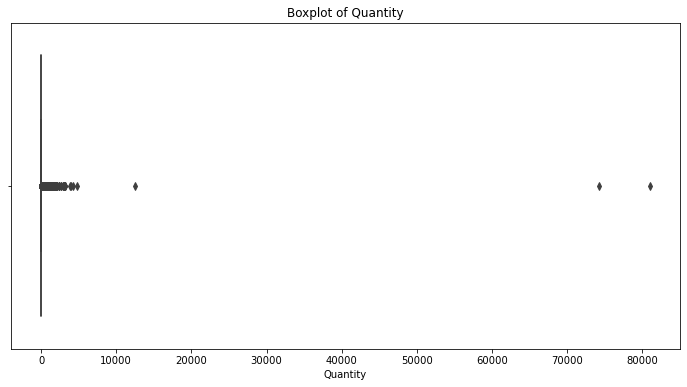

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df['Quantity'])

plt.title("Boxplot of Quantity")

plt.show()


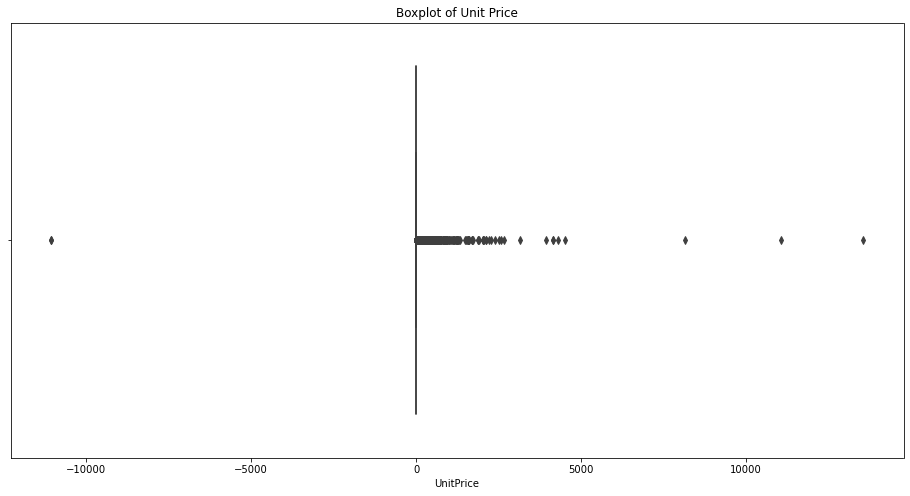

In [38]:
plt.figure(figsize=(16,8))

sns.boxplot(x=df['UnitPrice'])

plt.title("Boxplot of Unit Price")

plt.show()

## Observation: 
many points beyond the whiskers confirm the presence of outliers.

In [40]:
# Confirm Using the IQR Method
# For Quantity:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-14.0 26.0


## Observation
This means that, according to the Interquartile Range (IQR) method:

Any transaction with Quantity < -14 is considered an outlier.
Any transaction with Quantity > 26 is considered an outlier.

Since I have already removed transactions with negative quantities during data cleaning:

df = df[df['Quantity'] > 0]

the only remaining outliers are transactions where: Quantity > 26

In [41]:
# How many outliers are there?

outliers = df[df['Quantity'] > upper]

print("Number of Quantity Outliers:", len(outliers))

Number of Quantity Outliers: 27210


In [42]:
# View the outliers
outliers[['InvoiceNo',
          'Description',
          'Quantity',
          'UnitPrice',
          'Country']].head(20)

,InvoiceNo,Description,Quantity,UnitPrice,Country
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,United Kingdom
31,536370,INFLATABLE POLITICAL GLOBE,48,0.85,France
44,536370,MINI PAINT SET VINTAGE,36,0.65,France
46,536371,PAPER CHAIN KIT 50'S CHRISTMAS,80,2.55,United Kingdom
65,536374,VICTORIAN SEWING BOX LARGE,32,10.95,United Kingdom
82,536376,HOT WATER BOTTLE TEA AND SYMPATHY,48,3.45,United Kingdom
83,536376,RED HANGING HEART T-LIGHT HOLDER,64,2.55,United Kingdom
96,536378,PACK OF 72 RETROSPOT CAKE CASES,120,0.42,United Kingdom
101,536378,CHARLIE & LOLA WASTEPAPER BIN FLORA,48,1.25,United Kingdom
102,536378,RED CHARLIE+LOLA PERSONAL DOORSIGN,96,0.38,United Kingdom


In [43]:
# Percentage of outliers
percentage = (len(outliers) / len(df)) * 100

print(f"Percentage of Quantity Outliers: {percentage:.2f}%")

Percentage of Quantity Outliers: 5.18%


## Note: remove these outliers?

For Apriori, generally no.

The Apriori algorithm does not use the actual quantity values when mining association rules. After the basket transformation:

## Number of Transactions :

This tells us how many shopping baskets exist.

In [44]:
print("Total Transactions:",
      df['InvoiceNo'].nunique())


Total Transactions: 20136


## Top 20 Best Selling Products

In [46]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Country'],
      dtype='object')

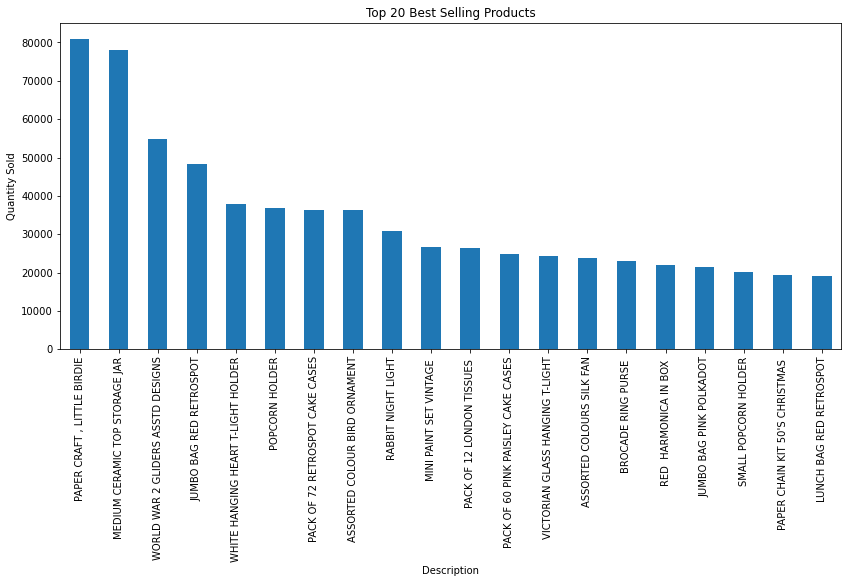

In [47]:
# Top 20 Best Selling Products
top_products = (df.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(20))

plt.figure(figsize=(14,6))

top_products.plot(kind='bar')

plt.title("Top 20 Best Selling Products")

plt.ylabel("Quantity Sold")

plt.show()

## Key Observations 

- PAPER CRAFT, LITTLE BIRDIE is the best-selling product, with over 80,000 units sold, making it the highest-volume product in the dataset.
- MEDIUM CERAMIC TOP STORAGE JAR is the second best-selling product, with approximately 78,000 units sold.
- WORLD WAR 2 GLIDERS ASSTD DESIGNS ranks third, with around 55,000 units sold.

Products such as:

WHITE HANGING HEART T-LIGHT HOLDER
POPCORN HOLDER
ASSORTED COLOUR BIRD ORNAMENT
PACK OF 72 RETROSPOT CAKE CASES

also exhibit consistently high sales volumes, indicating that they are popular products.

Most of the remaining products have sales between 20,000 and 40,000 units, suggesting a gradual decline rather than an abrupt drop. This indicates that several products are consistently purchased in large quantities.

## Transactions by Country 

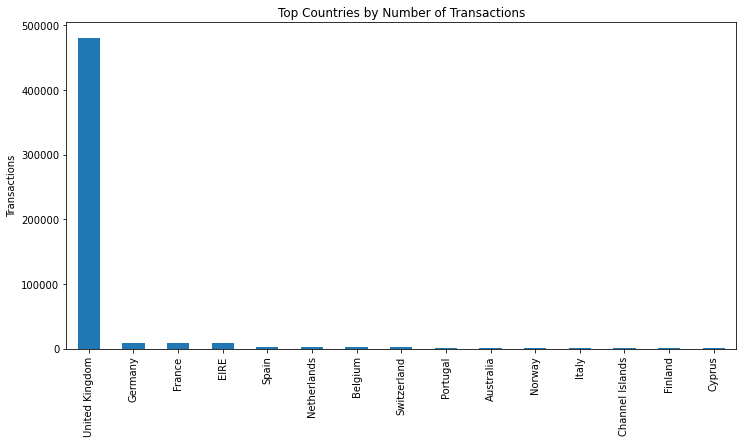

In [48]:
# Transactions by Country
plt.figure(figsize=(12,6))

df['Country'].value_counts().head(15).plot(kind='bar')

plt.title("Top Countries by Number of Transactions")

plt.ylabel("Transactions")

plt.show()

## Observation: United Kingdom dominates the dataset.

## Quantity Distribution

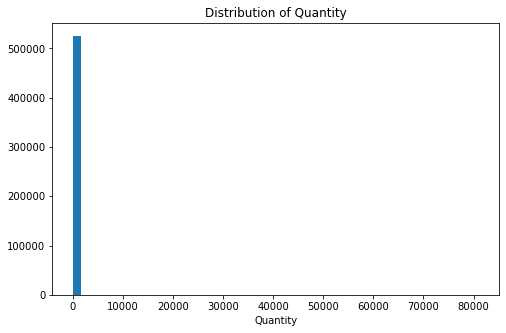

In [49]:
# Quantity Distribution
plt.figure(figsize=(8,5))

plt.hist(df['Quantity'],
         bins=50)

plt.title("Distribution of Quantity")

plt.xlabel("Quantity")

plt.show()

## Observation: Most purchases involve small quantities.

## Unit Price Distribution

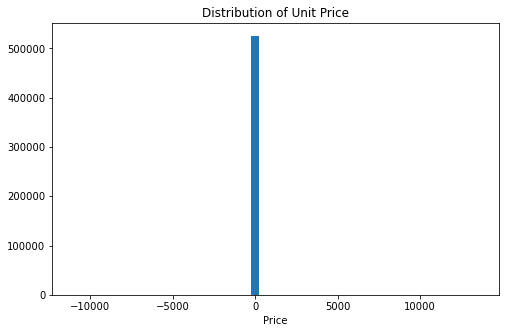

In [50]:
# Unit Price Distribution
plt.figure(figsize=(8,5))

plt.hist(df['UnitPrice'],
         bins=50)

plt.title("Distribution of Unit Price")

plt.xlabel("Price")

plt.show()


## Observation: Most products are inexpensive.

## Monthly Sales Trend

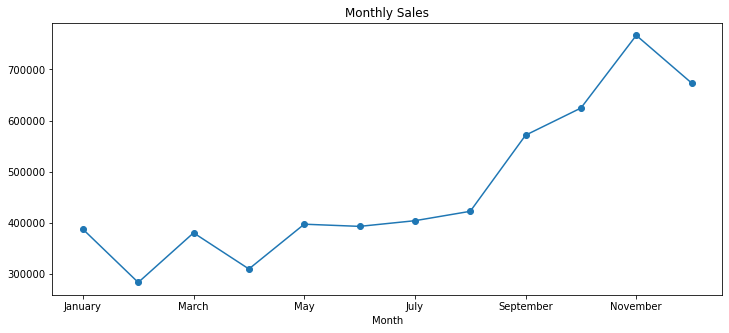

In [53]:
# Monthly Sales Trend

# Convert date:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create month:

df['Month'] = df['InvoiceDate'].dt.month_name()

# Plot:

monthly = df.groupby('Month')['Quantity'].sum()

monthly = monthly.reindex([
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'])

monthly.plot(figsize=(12,5),
             marker='o')

plt.title("Monthly Sales")

plt.show()

## Observation ffrom the plot

- The monthly sales trend reveals noticeable seasonal variations in customer purchasing behavior. 
- Sales were relatively stable during the first eight months of the year, with February recording the lowest sales volume. 
- Beginning in September, sales increased sharply, reaching their highest level in November before declining slightly in - December. 
- The strong performance during the final quarter suggests increased consumer spending associated with seasonal events such as holiday shopping and promotional campaigns. 
- These findings indicate that customer purchasing patterns are influenced by seasonality, which retailers can leverage for inventory planning and marketing strategies.

## Connection to the Apriori Algorithm

This trend also provides context for market basket analysis:

- During high-sales months such as November and December, there are more transactions available for analysis.
- More transactions often lead to more reliable frequent itemsets and stronger association rules, making these periods especially useful for discovering product purchasing patterns.

## Sales by Hour

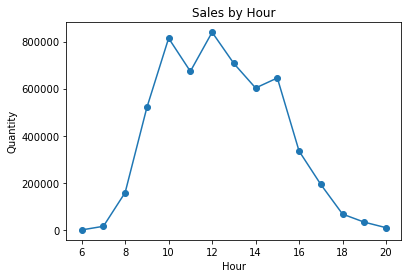

In [58]:
df['Hour'] = df['InvoiceDate'].dt.hour

hourly = df.groupby('Hour')['Quantity'].sum()

hourly.plot(marker='o')


plt.title("Sales by Hour")

plt.xlabel("Hour")

plt.ylabel("Quantity")

plt.show()

## Observation from plot

- The hourly sales analysis shows that customer purchasing activity is concentrated during normal business hours. 
- Sales begin to increase significantly after 8:00 AM, reaching their highest level around 12:00 PM. High sales volumes continue until approximately 3:00 PM, after which sales decline steadily throughout the evening. 
- Very few transactions occur during the early morning and late evening hours. 
- This pattern suggests that most purchases are made during regular business hours, providing valuable insights for staffing, inventory management, and promotional scheduling.

##  Revenue Distribution

In [59]:
# Create revenue:

df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Top revenue countries

country_sales = df.groupby('Country')['Revenue'].sum()

country_sales.sort_values(
ascending=False).head(10)

Country
United Kingdom    8979619.974
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

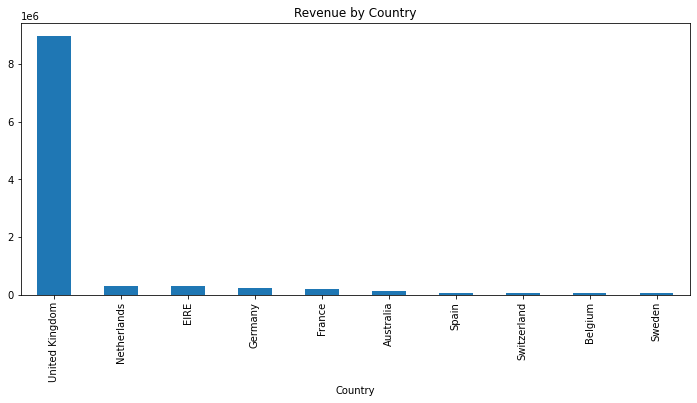

In [60]:
country_sales.sort_values(
ascending=False).head(10).plot(
kind='bar',
figsize=(12,5))

plt.title("Revenue by Country")

plt.show()

## Top Revenue Products

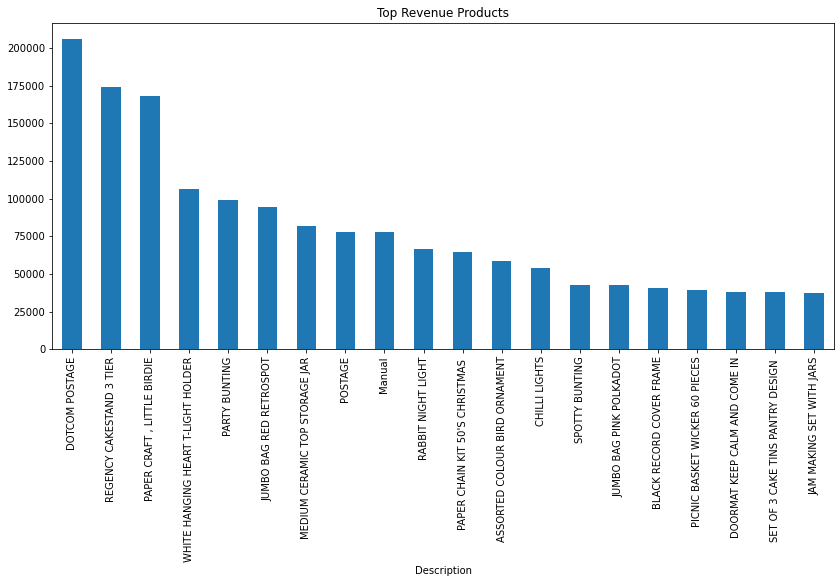

In [61]:
# Top Revenue Products
top_revenue = (df.groupby('Description')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(20))

top_revenue.plot(kind='bar',
                 figsize=(14,6))

plt.title("Top Revenue Products")

plt.show()

## Correlation Heatmap


Text(0.5, 1.0, 'Correlation Matrix')

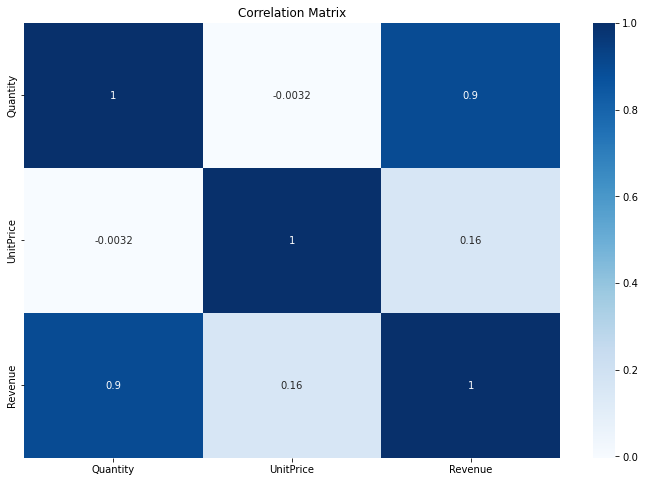

In [63]:
# Create numerical dataframe

numeric = df[['Quantity',
              'UnitPrice',
              'Revenue']]

# Plot

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")


## Observation:
- The correlation analysis revealed a strong positive relationship between Quantity and Revenue (r = 0.90), indicating that larger purchase quantities substantially increase sales revenue. 
- In contrast, Unit Price exhibited only a weak positive correlation with Revenue (r = 0.16), suggesting that sales volume has a greater impact on revenue than product price. 
- Additionally, the correlation between Quantity and Unit Price was approximately zero (r = -0.003), indicating that customers purchase products in varying quantities regardless of their individual prices.

## Step 4: Split by Region
- The United Kingdom was selected because it has the highest number of transactions in the dataset. 
- A larger number of transactions provides more reliable frequent itemsets and association rules. 
- Additionally, analyzing one region avoids mixing purchasing patterns from different countries.

In [66]:
basket=(df[df['Country']=='United Kingdom']
.groupby(['InvoiceNo','Description'])['Quantity']
.sum().unstack().fillna(0))
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 5: Hot Encode

In [67]:
def hot_encode(x):
    return 0 if x<=0 else 1
basket=basket.applymap(hot_encode)
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [69]:
basket = basket > 0

In [70]:
print(basket.shape)

(18194, 4058)


## Step 6: Build Apriori Model and Analyze Results

In [68]:
frequent_items=apriori(basket,min_support=0.02,use_colnames=True)
display(frequent_items.sort_values('support',ascending=False).head(20))

rules=association_rules(frequent_items,metric='confidence',min_threshold=0.5)
display(rules[['antecedents','consequents','support','confidence','lift']].sort_values('lift',ascending=False).head(20))

top=frequent_items.sort_values('support',ascending=False).head(20)
plt.figure(figsize=(12,6))
plt.bar(top['itemsets'].astype(str),top['support'])
plt.xticks(rotation=90)
plt.title('Top 20 Frequent Itemsets')
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(rules['support'],rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(rules['confidence'],rules['lift'])
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.show()

C:\Users\tiwal\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


MemoryError: Unable to allocate 11.8 GiB for an array with shape (43660, 2, 18194) and data type int64

# MemoryError: Unable to allocate 11.8 GiB for an array with shape (43660, 2, 18194) and data type int64

## For the algorithm to run successfully on my laptop while still producing meaningful association rules.

- I convert the basket to Boolean (basket = basket > 0).
- Remove very rare products (e.g., those appearing in fewer than 100 transactions).
- Use min_support=0.05.
- Set low_memory=True.
- Set max_len=2 or max_len=3.

In [78]:
# Convert to Boolean
basket = basket > 0

# Run Apriori

frequent_items = apriori(
    basket,
    min_support=0.005,      # 0.5%
    use_colnames=True,
    low_memory=True,
    max_len=2
)


rules = association_rules(
    frequent_items,
    metric='confidence',
    min_threshold=0.5
)

## Step 6: Building the models and analyzing the results

In [79]:
frequent_items.sort_values(
    by='support',
    ascending=False
).head(20)

,support,itemsets
1499,0.119050,(WHITE HANGING HEART T-LIGHT HOLDER)
694,0.106519,(JUMBO BAG RED RETROSPOT)
1088,0.092613,(REGENCY CAKESTAND 3 TIER)
923,0.087611,(PARTY BUNTING)
765,0.076509,(LUNCH BAG RED RETROSPOT)
96,0.075355,(ASSORTED COLOUR BIRD ORNAMENT)
1208,0.068209,(SET OF 3 CAKE TINS PANTRY DESIGN )
840,0.067000,(NATURAL SLATE HEART CHALKBOARD )
757,0.066835,(LUNCH BAG BLACK SKULL.)
619,0.063977,(HEART OF WICKER SMALL)


## Observation

- These are the products that appear most frequently in customer transactions.

## Check the Number of Frequent Itemsets

In [80]:
# Check the Number of Frequent Itemsets
print("Number of Frequent Itemsets:",
      len(frequent_items))

Number of Frequent Itemsets: 10775


## View the Association Rules

In [81]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(SPACEBOY BEAKER),( DOLLY GIRL BEAKER),0.008080,0.007750,0.005441,0.673469,86.901433,1.0,0.005379,3.038766,0.996544,0.523810,0.670919,0.687799
1,( DOLLY GIRL BEAKER),(SPACEBOY BEAKER),0.007750,0.008080,0.005441,0.702128,86.901433,1.0,0.005379,3.330019,0.996213,0.523810,0.699701,0.687799
2,( OVAL WALL MIRROR DIAMANTE ),(DOTCOM POSTAGE),0.008464,0.038914,0.005386,0.636364,16.353107,1.0,0.005057,2.642987,0.946864,0.128272,0.621640,0.387391
3,(3 DRAWER ANTIQUE WHITE WOOD CABINET),(WOOD 2 DRAWER CABINET WHITE FINISH),0.010553,0.029350,0.006046,0.572917,19.519936,1.0,0.005736,2.272741,0.958889,0.178571,0.560003,0.389455
4,(36 DOILIES VINTAGE CHRISTMAS),(60 CAKE CASES VINTAGE CHRISTMAS),0.008904,0.031934,0.005441,0.611111,19.136929,1.0,0.005157,2.489314,0.956260,0.153727,0.598283,0.390753


In [75]:
print(frequent_items.shape)
frequent_items.head()

(33, 2)


,support,itemsets
0,0.051116,(ALARM CLOCK BAKELIKE RED )
1,0.075355,(ASSORTED COLOUR BIRD ORNAMENT)
2,0.051336,(GREEN REGENCY TEACUP AND SAUCER)
3,0.050291,(HEART OF WICKER LARGE)
4,0.063977,(HEART OF WICKER SMALL)


In [76]:
frequent_items['length'] = frequent_items['itemsets'].apply(len)

frequent_items['length'].value_counts()

1    33
Name: length, dtype: int64

In [77]:
print(basket.shape)

(18194, 4058)


### The Apriori algorithm identified several strong association rules among products purchased by customers in the United Kingdom. 
- The strongest rule indicated that customers purchasing SPACEBOY BEAKER were highly likely to purchase DOLLY GIRL BEAKER, with a confidence of 67.35% and a lift of 86.90, demonstrating an exceptionally strong positive association. 
- Similar relationships were observed among complementary home décor, furniture, and seasonal products. 
- These findings suggest that the discovered associations can be used to support product recommendation systems, cross-selling strategies, bundled promotions, and inventory management. 
- Overall, the Apriori algorithm successfully uncovered meaningful purchasing patterns within the Online Retail dataset.

## Display the Most Important Columns

In [82]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']]

,antecedents,consequents,support,confidence,lift
0,(SPACEBOY BEAKER),( DOLLY GIRL BEAKER),0.005441,0.673469,86.901433
1,( DOLLY GIRL BEAKER),(SPACEBOY BEAKER),0.005441,0.702128,86.901433
2,( OVAL WALL MIRROR DIAMANTE ),(DOTCOM POSTAGE),0.005386,0.636364,16.353107
3,(3 DRAWER ANTIQUE WHITE WOOD CABINET),(WOOD 2 DRAWER CABINET WHITE FINISH),0.006046,0.572917,19.519936
4,(36 DOILIES VINTAGE CHRISTMAS),(60 CAKE CASES VINTAGE CHRISTMAS),0.005441,0.611111,19.136929
...,...,...,...,...,...
797,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.020226,0.722986,27.461402
798,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.020226,0.768267,27.461402
799,(WOODEN TREE CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.012751,0.748387,26.750795
800,(WOODEN TREE CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.014455,0.848387,32.224540


## Display the Top 20 Strongest Rules (Sorted by Lift)
- These are considered the strongest associations because lift measures how much more often two products are purchased together than would be expected by chance.

In [83]:

top_rules = rules[['antecedents',
                   'consequents',
                   'support',
                   'confidence',
                   'lift']].sort_values(
                   by='lift',
                   ascending=False)

top_rules.head(20)

,antecedents,consequents,support,confidence,lift
303,(DOLLY GIRL CHILDRENS BOWL),(DOLLY GIRL CHILDRENS CUP),0.005771,0.760870,98.179155
302,(DOLLY GIRL CHILDRENS CUP),(DOLLY GIRL CHILDRENS BOWL),0.005771,0.744681,98.179155
582,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.005112,0.641379,97.243793
583,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.005112,0.775000,97.243793
268,(CHRISTMAS TREE HEART DECORATION),(CHRISTMAS TREE DECORATION WITH BELL),0.006046,0.614525,89.445363
267,(CHRISTMAS TREE DECORATION WITH BELL),(CHRISTMAS TREE HEART DECORATION),0.006046,0.880000,89.445363
304,(SPACEBOY CHILDRENS BOWL),(DOLLY GIRL CHILDRENS BOWL),0.005222,0.659722,86.978160
305,(DOLLY GIRL CHILDRENS BOWL),(SPACEBOY CHILDRENS BOWL),0.005222,0.688406,86.978160
0,(SPACEBOY BEAKER),( DOLLY GIRL BEAKER),0.005441,0.673469,86.901433
1,( DOLLY GIRL BEAKER),(SPACEBOY BEAKER),0.005441,0.702128,86.901433


## Display the Top 20 Rules by Confidence
- Confidence measures the probability that customers who purchase the antecedent product will also purchase the consequent product.

In [84]:

rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].sort_values(
       by='confidence',
       ascending=False).head(20)

,antecedents,consequents,support,confidence,lift
334,(PINK BUTTERFLY HANDBAG W BOBBLES),(DOTCOM POSTAGE),0.005386,1.000000,25.697740
57,(BEADED CRYSTAL HEART GREEN ON STICK),(DOTCOM POSTAGE),0.009344,0.988372,25.398929
80,(BEADED CRYSTAL HEART PINK ON STICK),(DOTCOM POSTAGE),0.011048,0.975728,25.074009
165,(BOYS ALPHABET IRON ON PATCHES),(DOTCOM POSTAGE),0.005167,0.969072,24.902965
179,(CANDY SPOT CUSHION COVER),(DOTCOM POSTAGE),0.006486,0.959350,24.653117
354,(SOFT PINK ROSE TOWEL ),(DOTCOM POSTAGE),0.006266,0.934426,24.012642
479,(HERB MARKER THYME),(HERB MARKER ROSEMARY),0.011762,0.930435,73.282816
480,(HERB MARKER ROSEMARY),(HERB MARKER THYME),0.011762,0.926407,73.282816
464,(HERB MARKER CHIVES ),(HERB MARKER PARSLEY),0.010278,0.921182,73.508729
476,(HERB MARKER PARSLEY),(HERB MARKER ROSEMARY),0.011377,0.907895,71.507519


## Display Rules with High Confidence (≥ 70%)

In [85]:
rules[rules['confidence'] >= 0.70][[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]]

,antecedents,consequents,support,confidence,lift
1,( DOLLY GIRL BEAKER),(SPACEBOY BEAKER),0.005441,0.702128,86.901433
48,(BAKING SET SPACEBOY DESIGN),(BAKING SET 9 PIECE RETROSPOT ),0.015500,0.701493,16.176116
51,(KITCHEN METAL SIGN),(BATHROOM METAL SIGN),0.011982,0.721854,21.285927
52,(TOILET METAL SIGN),(BATHROOM METAL SIGN),0.015829,0.729114,21.499998
53,(BEADED CRYSTAL HEART GREEN ON STICK),(BEADED CRYSTAL HEART PINK ON STICK),0.007530,0.796512,70.348216
...,...,...,...,...,...
794,(WOOD STOCKING CHRISTMAS SCANDISPOT),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.006760,0.710983,27.005467
797,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.020226,0.722986,27.461402
798,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.020226,0.768267,27.461402
799,(WOODEN TREE CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.012751,0.748387,26.750795


## Display Rules with High Lift (>2)

In [86]:

rules[rules['lift'] > 2][[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].sort_values(
    by='lift',
    ascending=False
)


,antecedents,consequents,support,confidence,lift
303,(DOLLY GIRL CHILDRENS BOWL),(DOLLY GIRL CHILDRENS CUP),0.005771,0.760870,98.179155
302,(DOLLY GIRL CHILDRENS CUP),(DOLLY GIRL CHILDRENS BOWL),0.005771,0.744681,98.179155
582,(PACK OF 6 SKULL PAPER PLATES),(PACK OF 6 SKULL PAPER CUPS),0.005112,0.641379,97.243793
583,(PACK OF 6 SKULL PAPER CUPS),(PACK OF 6 SKULL PAPER PLATES),0.005112,0.775000,97.243793
268,(CHRISTMAS TREE HEART DECORATION),(CHRISTMAS TREE DECORATION WITH BELL),0.006046,0.614525,89.445363
...,...,...,...,...,...
521,(JUMBO BAG VINTAGE DOILY ),(JUMBO BAG RED RETROSPOT),0.018138,0.503817,4.729847
103,(BEADED CRYSTAL HEART PINK ON STICK),(WHITE HANGING HEART T-LIGHT HOLDER),0.006156,0.543689,4.566890
738,(SET/4 RED MINI ROSE CANDLE IN BOWL),(WHITE HANGING HEART T-LIGHT HOLDER),0.005551,0.537234,4.512667
76,(BEADED CRYSTAL HEART GREEN ON STICK),(WHITE HANGING HEART T-LIGHT HOLDER),0.005002,0.529070,4.444088


## Display Rules with High Support

In [87]:
rules.sort_values(
    by='support',
    ascending=False
)[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].head(20)

,antecedents,consequents,support,confidence,lift
511,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.043146,0.677308,6.358587
424,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.038529,0.732497,14.268798
425,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.038529,0.750535,14.268798
525,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.038364,0.617699,5.798977
523,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.036111,0.579876,5.443897
418,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.031714,0.820768,15.988282
419,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.031714,0.617773,15.988282
499,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.031329,0.626374,5.880414
37,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.030944,0.605376,12.573307
36,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.030944,0.642694,12.573307


## Convert Frozensets to Readable Text

- The antecedents and consequents columns are stored as frozensets. To display them as readable text:

In [89]:
rules_display = rules.copy()

rules_display['Antecedent'] = rules_display['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules_display['Consequent'] = rules_display['consequents'].apply(
    lambda x: ', '.join(list(x))
)

rules_display[['Antecedent',
               'Consequent',
               'support',
               'confidence',
               'lift']].head(20)

,Antecedent,Consequent,support,confidence,lift
0,SPACEBOY BEAKER,DOLLY GIRL BEAKER,0.005441,0.673469,86.901433
1,DOLLY GIRL BEAKER,SPACEBOY BEAKER,0.005441,0.702128,86.901433
2,OVAL WALL MIRROR DIAMANTE,DOTCOM POSTAGE,0.005386,0.636364,16.353107
3,3 DRAWER ANTIQUE WHITE WOOD CABINET,WOOD 2 DRAWER CABINET WHITE FINISH,0.006046,0.572917,19.519936
4,36 DOILIES VINTAGE CHRISTMAS,60 CAKE CASES VINTAGE CHRISTMAS,0.005441,0.611111,19.136929
5,3D VINTAGE CHRISTMAS STICKERS,3D TRADITIONAL CHRISTMAS STICKERS,0.005167,0.525140,51.367694
6,3D TRADITIONAL CHRISTMAS STICKERS,3D VINTAGE CHRISTMAS STICKERS,0.005167,0.505376,51.367694
7,6 GIFT TAGS VINTAGE CHRISTMAS,6 GIFT TAGS 50'S CHRISTMAS,0.008080,0.508651,31.693108
8,6 GIFT TAGS 50'S CHRISTMAS,6 GIFT TAGS VINTAGE CHRISTMAS,0.008080,0.503425,31.693108
9,6 GIFT TAGS 50'S CHRISTMAS,ROLL WRAP 50'S CHRISTMAS,0.008849,0.551370,30.215733


## Display the Top 10 Rules

In [90]:

top10 = rules_display.sort_values(
    by='lift',
    ascending=False
).head(10)

print(top10[['Antecedent',
             'Consequent',
             'support',
             'confidence',
             'lift']])


                              Antecedent                           Consequent  \
303            DOLLY GIRL CHILDRENS BOWL             DOLLY GIRL CHILDRENS CUP   
302             DOLLY GIRL CHILDRENS CUP            DOLLY GIRL CHILDRENS BOWL   
582         PACK OF 6 SKULL PAPER PLATES           PACK OF 6 SKULL PAPER CUPS   
583           PACK OF 6 SKULL PAPER CUPS         PACK OF 6 SKULL PAPER PLATES   
268      CHRISTMAS TREE HEART DECORATION  CHRISTMAS TREE DECORATION WITH BELL   
267  CHRISTMAS TREE DECORATION WITH BELL      CHRISTMAS TREE HEART DECORATION   
304              SPACEBOY CHILDRENS BOWL            DOLLY GIRL CHILDRENS BOWL   
305            DOLLY GIRL CHILDRENS BOWL              SPACEBOY CHILDRENS BOWL   
0                        SPACEBOY BEAKER                    DOLLY GIRL BEAKER   
1                      DOLLY GIRL BEAKER                      SPACEBOY BEAKER   

      support  confidence       lift  
303  0.005771    0.760870  98.179155  
302  0.005771    0.744681  98.

## Interpret the Rules Automatically

In [91]:

top10 = rules_display.sort_values(
    by='lift',
    ascending=False
).head(10)

for _, row in top10.iterrows():

    print(f"If a customer buys '{row['Antecedent']}',")
    print(f"they are likely to buy '{row['Consequent']}'.")

    print(f"Support    : {row['support']:.4f}")
    print(f"Confidence : {row['confidence']:.2%}")
    print(f"Lift       : {row['lift']:.2f}")

    print("-"*60)

If a customer buys 'DOLLY GIRL CHILDRENS BOWL',
they are likely to buy 'DOLLY GIRL CHILDRENS CUP'.
Support    : 0.0058
Confidence : 76.09%
Lift       : 98.18
------------------------------------------------------------
If a customer buys 'DOLLY GIRL CHILDRENS CUP',
they are likely to buy 'DOLLY GIRL CHILDRENS BOWL'.
Support    : 0.0058
Confidence : 74.47%
Lift       : 98.18
------------------------------------------------------------
If a customer buys 'PACK OF 6 SKULL PAPER PLATES',
they are likely to buy 'PACK OF 6 SKULL PAPER CUPS'.
Support    : 0.0051
Confidence : 64.14%
Lift       : 97.24
------------------------------------------------------------
If a customer buys 'PACK OF 6 SKULL PAPER CUPS',
they are likely to buy 'PACK OF 6 SKULL PAPER PLATES'.
Support    : 0.0051
Confidence : 77.50%
Lift       : 97.24
------------------------------------------------------------
If a customer buys 'CHRISTMAS TREE HEART DECORATION',
they are likely to buy 'CHRISTMAS TREE DECORATION WITH BELL'

## Save the Rules to Excel

In [92]:

rules_display[['Antecedent',
               'Consequent',
               'support',
               'confidence',
               'lift']].to_excel(
               "Association_Rules.xlsx",
               index=False)

## Plot the Top 20 Rules by Lift

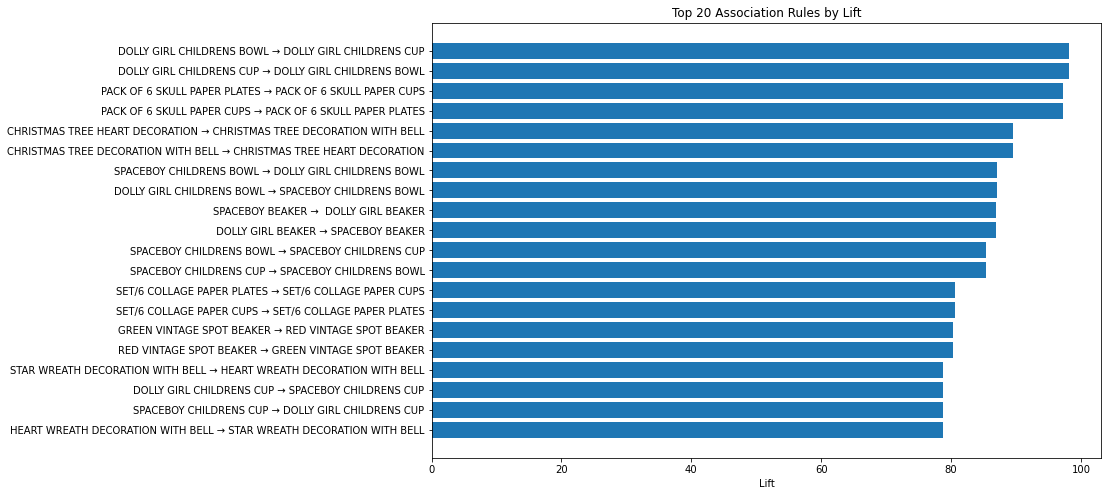

In [93]:
import matplotlib.pyplot as plt

top20 = rules_display.sort_values(
    by='lift',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20['Antecedent'] + " → " + top20['Consequent'],
    top20['lift']
)

plt.xlabel("Lift")

plt.title("Top 20 Association Rules by Lift")

plt.gca().invert_yaxis()

plt.show()



## Scatter Plot of Support vs Confidence

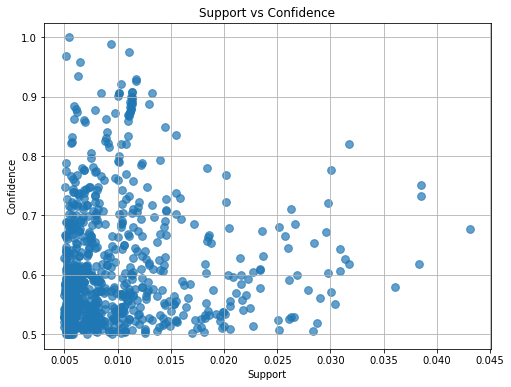

In [94]:

plt.figure(figsize=(8,6))

plt.scatter(
    rules['support'],
    rules['confidence'],
    s=60,
    alpha=0.7
)

plt.xlabel("Support")

plt.ylabel("Confidence")

plt.title("Support vs Confidence")

plt.grid(True)

plt.show()

## Observation:
- The Support vs Confidence scatter plot illustrates the relationship between the frequency and reliability of the generated association rules. Most rules have relatively low support (below 2%), indicating that the corresponding product combinations occur in a small proportion of transactions. 
- However, many rules exhibit confidence values between 50% and 75%, suggesting that these product associations are reliable when the antecedent product is purchased. A small number of rules achieve both high support and high confidence, representing the most valuable product associations for recommendation systems and marketing strategies.

## Scatter Plot of Confidence vs Lift

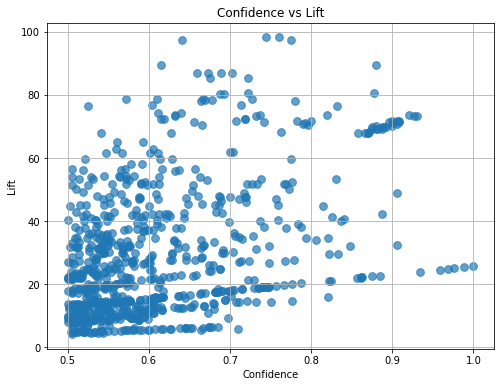

In [95]:
## Scatter Plot of Confidence vs Lift
plt.figure(figsize=(8,6))

plt.scatter(
    rules['confidence'],
    rules['lift'],
    s=60,
    alpha=0.7
)

plt.xlabel("Confidence")

plt.ylabel("Lift")

plt.title("Confidence vs Lift")

plt.grid(True)

plt.show()

## Observation:
- The Confidence vs Lift scatter plot illustrates the relationship between the reliability and strength of the generated association rules. 
- Most rules exhibit confidence values between 50% and 70%, indicating that customers who purchase the antecedent product are reasonably likely to purchase the consequent product. 
- The majority of rules also have lift values substantially greater than 1, confirming positive associations between products. 
- Several rules display both high confidence and exceptionally high lift values, representing the strongest product relationships within the dataset. 
- These rules are particularly valuable for recommendation systems, product bundling, and targeted marketing.